# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Muahammad Fawaid As'ad
- Email: muhammadfawaidasad@gmail.com
- Id Dicoding:fawaid27

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

### Menyiapkan data yang akan digunakan

## Data Understanding

Employee Data

The data contains demographic details, work-related metrics and attrition flag.

    EmployeeId - Employee Identifier
    Attrition - Did the employee attrition? (0=no, 1=yes)
    Age - Age of the employee
    BusinessTravel - Travel commitments for the job
    DailyRate - Daily salary
    Department - Employee Department
    DistanceFromHome - Distance from work to home (in km)
    Education - 1-Below College, 2-College, 3-Bachelor, 4-Master,5-Doctor
    EducationField - Field of Education
    EnvironmentSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
    Gender - Employee's gender
    HourlyRate - Hourly salary
    JobInvolvement - 1-Low, 2-Medium, 3-High, 4-Very High
    JobLevel - Level of job (1 to 5)
    JobRole - Job Roles
    JobSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
    MaritalStatus - Marital Status
    MonthlyIncome - Monthly salary
    MonthlyRate - Mounthly rate
    NumCompaniesWorked - Number of companies worked at
    Over18 - Over 18 years of age?
    OverTime - Overtime?
    PercentSalaryHike - The percentage increase in salary last year
    PerformanceRating - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
    RelationshipSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
    StandardHours - Standard Hours
    StockOptionLevel - Stock Option Level
    TotalWorkingYears - Total years worked
    TrainingTimesLastYear - Number of training attended last year
    WorkLifeBalance - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
    YearsAtCompany - Years at Company
    YearsInCurrentRole - Years in the current role
    YearsSinceLastPromotion - Years since the last promotion
    YearsWithCurrManager - Years with the current manager


In [2]:
# Import Dataset
emp = pd.read_csv("employee_data.csv")

In [3]:
# Menghitung jumlah baris dan kolom
print("Data shape:", emp.shape)

Data shape: (1470, 35)


In [4]:
# Menampilkan 5 data pertama
emp.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [5]:
# Menampilkan jumlah data dan bentuk type data
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [6]:
# deskripsi dai dataset yang memili type float atau integer
emp.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
#mendeteksi missing value
print("\nNull Values:")
print(emp.isnull().sum())


Null Values:
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance           

In [8]:
#menampilkan jumlah emplooy yang attrition dan tidak
print("Attrition Value Counts:")
print(emp["Attrition"].value_counts())

Attrition Value Counts:
0.0    879
1.0    179
Name: Attrition, dtype: int64


In [9]:
#menampilkan jumlah data duplikat
emp.duplicated().sum()

0

**Explorasi Data Analisis**

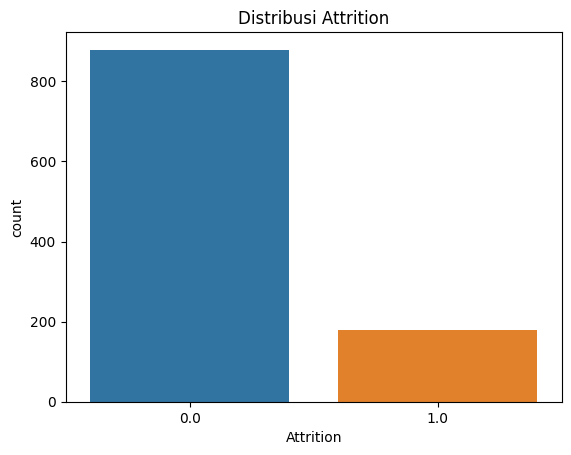

In [10]:
#distribusi Attrition
sns.countplot(data=emp, x="Attrition")
plt.title("Distribusi Attrition")
plt.show()

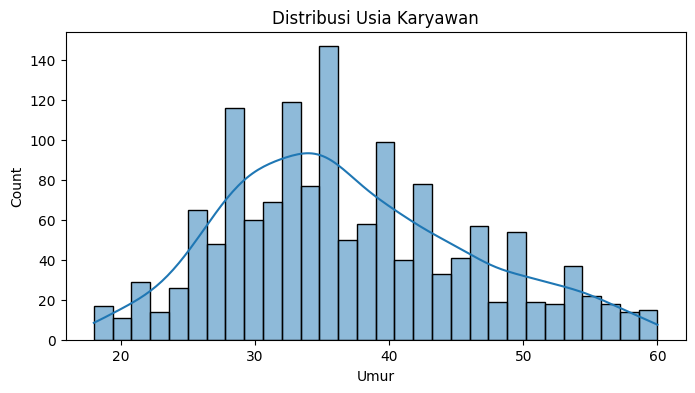

In [11]:
# Distribusi usia
plt.figure(figsize=(8, 4))
sns.histplot(emp['Age'], bins=30, kde=True)
plt.title("Distribusi Usia Karyawan")
plt.xlabel("Umur")
plt.show()

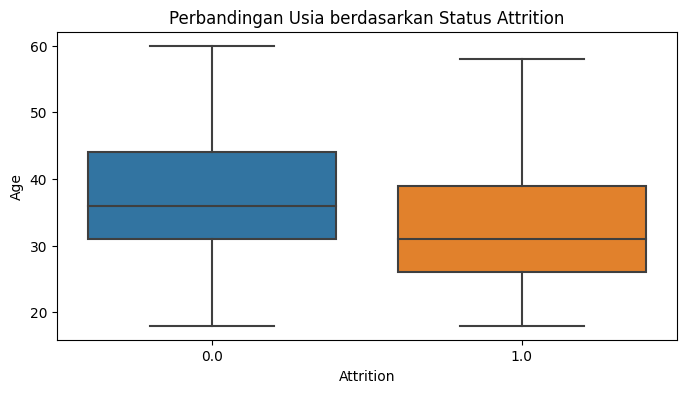

In [12]:
# Attrition berdasarkan usia
plt.figure(figsize=(8, 4))
sns.boxplot(x='Attrition', y='Age', data=emp)
plt.title("Perbandingan Usia berdasarkan Status Attrition")
plt.show()

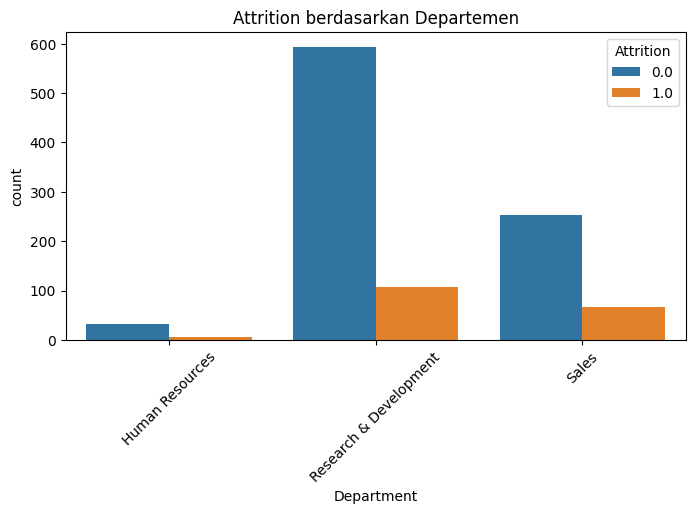

In [13]:
# Attrition berdasarkan Departemen
plt.figure(figsize=(8, 4))
sns.countplot(data=emp, x='Department', hue='Attrition')
plt.title("Attrition berdasarkan Departemen")
plt.xticks(rotation=45)
plt.show()

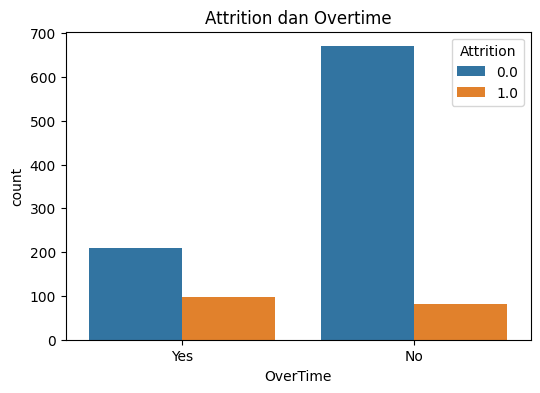

In [14]:
# Attrition berdasarkan OverTime
plt.figure(figsize=(6, 4))
sns.countplot(data=emp, x='OverTime', hue='Attrition')
plt.title("Attrition dan Overtime")
plt.show()

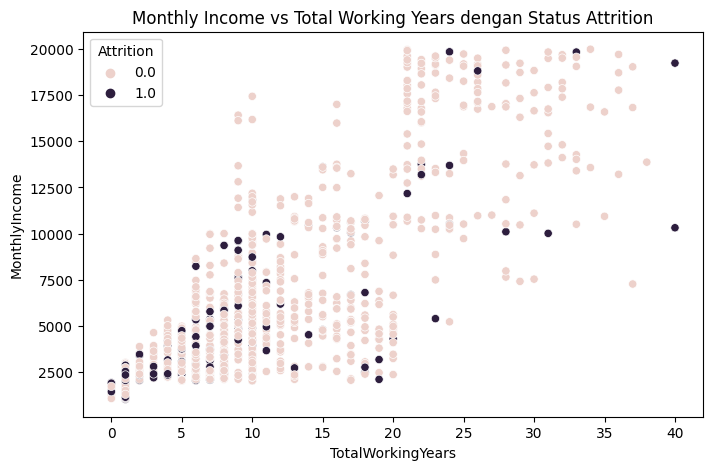

In [15]:
# Jam kerja dan Attrition
if 'MonthlyIncome' in emp.columns and 'TotalWorkingYears' in emp.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=emp, x='TotalWorkingYears', y='MonthlyIncome', hue='Attrition')
    plt.title("Monthly Income vs Total Working Years dengan Status Attrition")
    plt.show()


In [16]:
#memilih data selain object untuk map korelasi antar fitur
emp_corr = emp.copy()
cat_cols = emp_corr.select_dtypes(include='object').columns

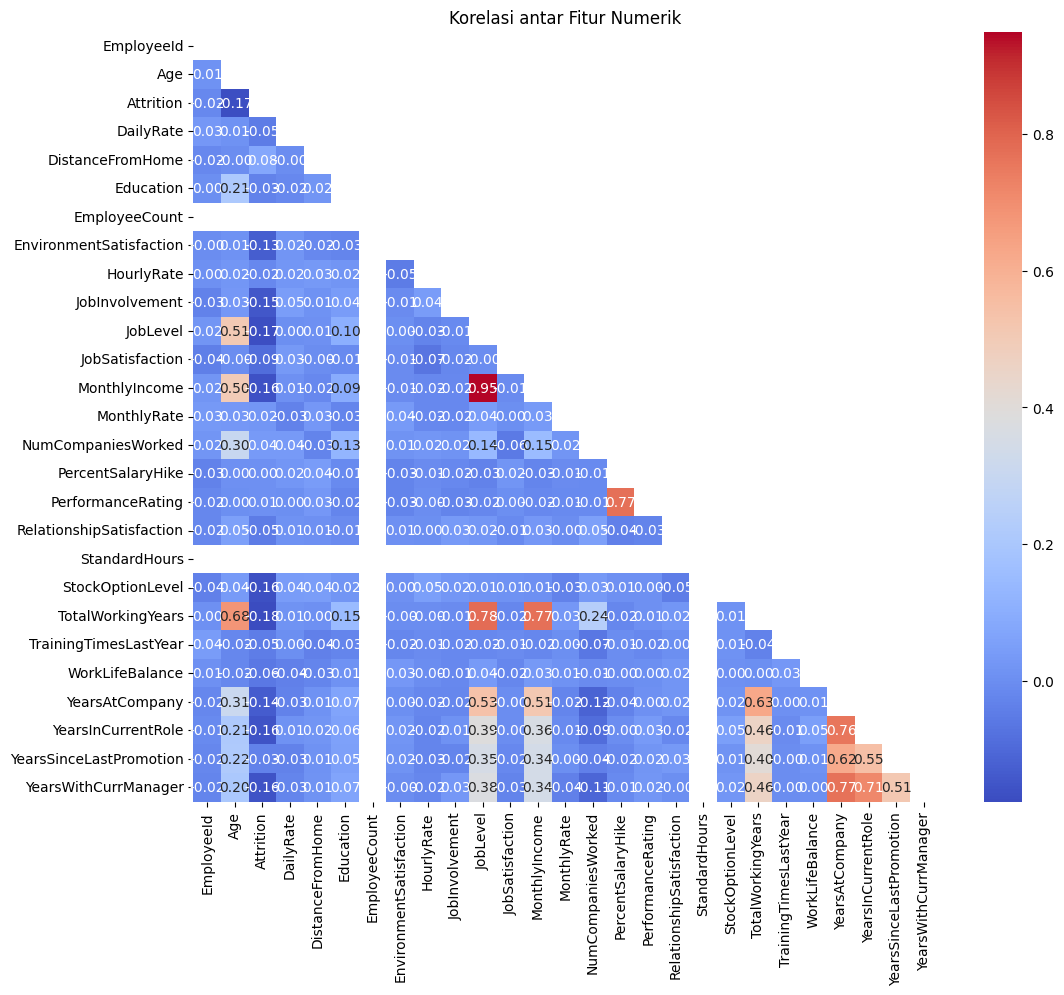

In [17]:
# Korelasi antar fitur numerik
plt.figure(figsize=(12, 10))
corr = emp_corr.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", mask=np.triu(corr))
plt.title("Korelasi antar Fitur Numerik")
plt.show()

## Data Preparation / Preprocessing

In [18]:
# Hapus semua baris yang memiliki nilai NaN
emp.dropna(inplace=True)
print("Setelah dropna, ukuran data:", emp.shape)
print("\nNull Values:")
print(emp.isnull().sum())

Setelah dropna, ukuran data: (1058, 35)

Null Values:
EmployeeId                  0
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany  

In [19]:
# Simpan data yang sudah dibersihkan ke file CSV
emp.to_csv("employee_cleaned.csv", index=False)

print("Data berhasil disimpan ke employee_cleaned.csv")

Data berhasil disimpan ke employee_cleaned.csv


In [20]:
emp_clean = emp.copy()
cat_cols = emp_clean.select_dtypes(include='object').columns

In [21]:
# hitung korelasi
numeric_df = emp_clean.select_dtypes(include=["int64", "float64"])
correlations = numeric_df.corr()["Attrition"].sort_values(ascending=False)

# Tampilkan korelasi
print("Korelasi fitur terhadap Attrition:")
print(correlations)


Korelasi fitur terhadap Attrition:
Attrition                   1.000000
DistanceFromHome            0.078074
NumCompaniesWorked          0.037429
MonthlyRate                 0.023299
PerformanceRating           0.007755
PercentSalaryHike           0.004907
HourlyRate                 -0.017524
EmployeeId                 -0.017912
YearsSinceLastPromotion    -0.031944
Education                  -0.032631
TrainingTimesLastYear      -0.047859
DailyRate                  -0.051992
RelationshipSatisfaction   -0.053417
WorkLifeBalance            -0.059556
JobSatisfaction            -0.091751
EnvironmentSatisfaction    -0.132848
YearsAtCompany             -0.135134
JobInvolvement             -0.150196
YearsWithCurrManager       -0.155962
YearsInCurrentRole         -0.158757
MonthlyIncome              -0.163600
StockOptionLevel           -0.164228
JobLevel                   -0.169201
Age                        -0.172067
TotalWorkingYears          -0.177137
EmployeeCount                    NaN
Sta

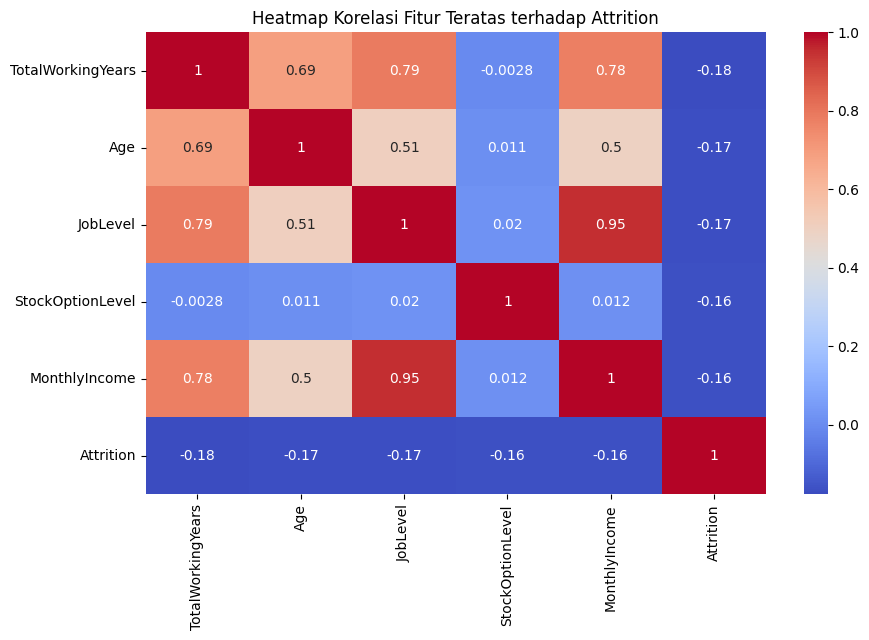

In [22]:
# Top 10 fitur yang paling berkorelasi dengan Attrition
top_corr = correlations.drop("Attrition").abs().sort_values(ascending=False).head(5).index

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df[top_corr.tolist() + ["Attrition"]].corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi Fitur Teratas terhadap Attrition")
plt.show()

In [23]:
#encoding data
le = LabelEncoder()
for col in cat_cols:
    emp_clean[col] = le.fit_transform(emp_clean[col])

In [24]:
# 5 fitur yang paling berkorelasi terhadap Attrition dan domain knowledge
top_features = ['TotalWorkingYears', 'Age', 'JobLevel', 'StockOptionLevel', 'MonthlyIncome', 'JobSatisfaction', 'OverTime', 'EnvironmentSatisfaction', 'YearsAtCompany']

# X dan y
X_top = emp_clean[top_features]
y = emp_clean['Attrition']

In [25]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42, stratify=y)


## Modeling

In [26]:
 #Inisialisasi model
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}


## Evaluation

In [27]:
# Training dan evaluasi
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n📌 Model: {name}")
    print("Akurasi:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


📌 Model: Random Forest
Akurasi: 0.8490566037735849
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.96      0.91       176
         1.0       0.61      0.31      0.41        36

    accuracy                           0.85       212
   macro avg       0.74      0.63      0.66       212
weighted avg       0.83      0.85      0.83       212


📌 Model: Gradient Boosting
Akurasi: 0.8349056603773585
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.95      0.91       176
         1.0       0.53      0.28      0.36        36

    accuracy                           0.83       212
   macro avg       0.70      0.61      0.63       212
weighted avg       0.81      0.83      0.81       212


📌 Model: XGBoost
Akurasi: 0.8160377358490566
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.90      0.89       176
         1.

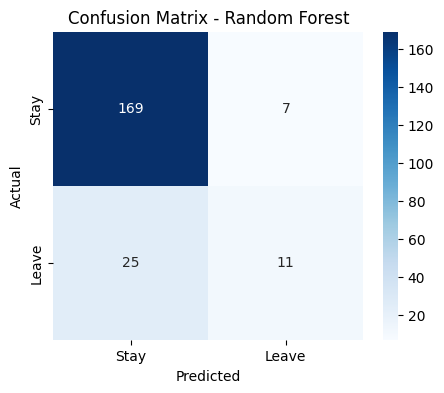

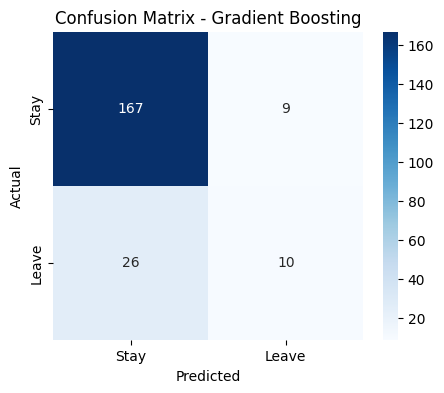

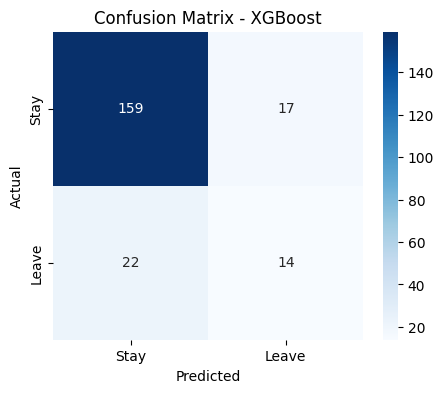

In [28]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Berdasrkan pelatihan 3 model maka didapatkan model yang terbaik dari fitur yang dipilih yaitu model random forest dengan nilai akurasi Akurasi: 0.8490566037735849

In [29]:
# Ambil satu baris dari X_test sebagai contoh input
sample = X_test.iloc[[0]]  # gunakan [[...]] agar tetap berbentuk DataFrame

# Gunakan model Random Forest untuk prediksi
prediction = models['Random Forest'].predict(sample)

# Tampilkan hasil
print("📌 Contoh Prediksi:")
print("Fitur input:")
print(sample)
print("Hasil prediksi:", "Leave" if prediction[0] == 1 else "Stay")


📌 Contoh Prediksi:
Fitur input:
     TotalWorkingYears  Age  JobLevel  StockOptionLevel  MonthlyIncome  \
958                 10   38         3                 0           7351   

     JobSatisfaction  OverTime  EnvironmentSatisfaction  YearsAtCompany  
958                2         0                        4               1  
Hasil prediksi: Stay


In [30]:
# Ambil satu sampel dari X_test
index = 0  # ganti ini jika ingin cek baris lain
sample = X_test.iloc[[index]]  # ambil data fitur
true_label = y_test.iloc[index]  # ambil label sebenarnya

# Prediksi menggunakan model
prediction = models['Random Forest'].predict(sample)[0]

# Tampilkan hasil
print("📌 Prediksi Model:", "Leave" if prediction == 1 else "Stay")
print("✅ Label Sebenarnya:", "Leave" if true_label == 1 else "Stay")

# Cek apakah prediksi benar atau salah
if prediction == true_label:
    print("🎉 Hasil prediksi BENAR!")
else:
    print("❌ Hasil prediksi SALAH.")


📌 Prediksi Model: Stay
✅ Label Sebenarnya: Stay
🎉 Hasil prediksi BENAR!


In [31]:
# Simpan model terbaik (Random Forest)
best_model = models['Random Forest']
joblib.dump(best_model, 'random_forest_model.pkl')

print("✅ Model Random Forest berhasil disimpan sebagai 'random_forest_model.pkl'")


✅ Model Random Forest berhasil disimpan sebagai 'random_forest_model.pkl'


In [32]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
